# Implementing the LCU method to solve a PDE

# preparation

## Define necessary modules

In [1]:
# make use of QLS jupyter env
import numpy as np
import scipy as sc
import time
from numerical_solvers.thomas_algorithm import numerical_solvers
from scipy.sparse import diags
import matplotlib.pyplot as plt
import warnings

# remove print limits
np.set_printoptions(threshold=np.inf)
warnings.simplefilter('ignore')

## Define utility functions

In [2]:
def solve_1DThomas(matrix, vector):
    '''
    Solves the 1D Thomas algorithm
    '''
    
    # Compare to thomas
    matrix1 = matrix.copy()
    vector1 = vector.copy()
    thomas = numerical_solvers()
    num_solution = thomas.solve_tridiagonal_thomas(matrix1, vector1)
    #num_solution = np.concatenate(([0], num_solution, [0]))
    #num_solution = normalize(num_solution, -1.0, 1.0)
    return num_solution

def construct_TT_matrix(main_diag, off_diag, size):
    '''
    Construct a tridiagonal Toeplitz matrix using the main diagonal and off-diagonal elements.
    '''
    matrix = diags([off_diag, main_diag, off_diag], offsets=[-1, 0, 1], shape=(size, size)).toarray()
    
    print(f'Matrix Condition number: {np.linalg.cond(matrix)}')
    return matrix

# Main script

Matrix Condition number: 9.472135954999578
Constructed matrix:
[[ 2. -1.  0.  0.]
 [-1.  2. -1.  0.]
 [ 0. -1.  2. -1.]
 [ 0.  0. -1.  2.]]


In [3]:
import numpy as np
import scipy

# the size of the unitary which block encodes A
REG_SIZE = 3


def get_random_unitary(num_qubits, seed=4):
    np.random.seed(seed)
    X = np.random.rand(2**num_qubits, 2**num_qubits)
    U, s, V = np.linalg.svd(X)
    return U @ V.T


U_a = get_random_unitary(REG_SIZE)

A_dim = int(U_a.shape[0] / 2)
A = U_a[:A_dim, :A_dim]
print(A)

[[-0.05338002 -0.36103662 -0.54016489 -0.39026125]
 [-0.33304121  0.10648228  0.37346704 -0.33977916]
 [ 0.4167817  -0.75180519  0.17593867  0.20944773]
 [ 0.26891079 -0.05333795 -0.32668787 -0.33602829]]


In [4]:
assert not (np.linalg.svd(A)[1] > 1).sum()

b = np.arange(A_dim)
b = b / np.linalg.norm(b)
print(b)

[0.         0.26726124 0.53452248 0.80178373]


In [5]:
kappa = max(1 / np.linalg.svd(A)[1])
print(kappa)
np.linalg.svd(A)[1]
print(np.linalg.svd(A)[1])

3.459862838470871
[0.99132079 0.84978294 0.52403662 0.2890288 ]


In [6]:
from classiq import *
from classiq.qmod.symbolic import floor
import pyqsp


@qfunc
def my_projector_controlled_phase(
    phase: CReal,
    proj_cnot: QCallable[QArray[QBit], QBit],
    state: QArray[QBit],
    aux: QBit,
) -> None:
    proj_cnot(state, aux)
    RZ(phase, aux)
    proj_cnot(state, aux)


@qfunc
def my_qsvt_step(
    phase1: CReal,
    phase2: CReal,
    proj_cnot_1: QCallable[QArray[QBit], QBit],
    proj_cnot_2: QCallable[QArray[QBit], QBit],
    u: QCallable[QArray[QBit]],
    state: QArray[QBit],
    aux: QBit,
):
    u(state)
    my_projector_controlled_phase(phase1, proj_cnot_2, state, aux)
    invert(lambda: u(state))
    my_projector_controlled_phase(phase2, proj_cnot_1, state, aux)


@qfunc
def my_qsvt(
    phase_seq: CArray[CReal],
    proj_cnot_1: QCallable[QArray[QBit], QBit],
    proj_cnot_2: QCallable[QArray[QBit], QBit],
    u: QCallable[QArray[QBit]],
    state: QArray[QBit],
    aux: QBit,
) -> None:
    H(aux)

    my_projector_controlled_phase(phase_seq[0], proj_cnot_1, state, aux)
    repeat(
        count=floor((phase_seq.len - 1) / 2),
        iteration=lambda index: my_qsvt_step(
            phase_seq[2 * index + 1],
            phase_seq[2 * index + 2],
            proj_cnot_1,
            proj_cnot_2,
            u,
            state,
            aux,
        ),
    )

    if_(
        condition=phase_seq.len % 2 == 1,
        then=lambda: IDENTITY(state),
        else_=lambda: (
            u(state),
            my_projector_controlled_phase(
                phase_seq[phase_seq.len - 1],
                proj_cnot_2,
                state,
                aux,
            ),
        ),
    )

    H(aux)

In [7]:
@qfunc
def my_qsvt_inversion(
    phase_seq: CArray[CReal],
    u: QCallable[QArray[QBit]],
    state: QArray[QBit],
    aux: Output[QBit],
) -> None:
    allocate(1, aux)

    def _projector_cnot(state: QArray[QBit], aux: QBit):
        X(state[state.len - 1])
        CX(state[state.len - 1], aux)
        X(state[state.len - 1])

    my_qsvt(
        phase_seq,
        lambda arg0, arg1: _projector_cnot(arg0, arg1),
        lambda arg0, arg1: _projector_cnot(arg0, arg1),
        u,
        state,
        aux,
    )

In [8]:
pg = pyqsp.poly.PolyOneOverX()
pcoefs = pg.generate(epsilon=0.05, kappa=kappa)

b=50, j0=20
[PolyOneOverX] minimum [-4.54115308] is at [-0.15883407]: normalizing
[PolyOneOverX] bounding to 0.5
[pyqsp.PolyOneOverX] pcoefs=[ 0.00000000e+00  5.50501781e+00  0.00000000e+00 -1.34815163e+02
  0.00000000e+00  2.15191868e+03  0.00000000e+00 -2.50709632e+04
  0.00000000e+00  2.25502975e+05  0.00000000e+00 -1.61156021e+06
  0.00000000e+00  9.27860774e+06  0.00000000e+00 -4.33007019e+07
  0.00000000e+00  1.64161062e+08  0.00000000e+00 -5.05820849e+08
  0.00000000e+00  1.26571548e+09  0.00000000e+00 -2.56671992e+09
  0.00000000e+00  4.20178645e+09  0.00000000e+00 -5.51711201e+09
  0.00000000e+00  5.75258027e+09  0.00000000e+00 -4.69115938e+09
  0.00000000e+00  2.92363543e+09  0.00000000e+00 -1.34306985e+09
  0.00000000e+00  4.28212620e+08  0.00000000e+00 -8.45647522e+07
  0.00000000e+00  7.78663704e+06]


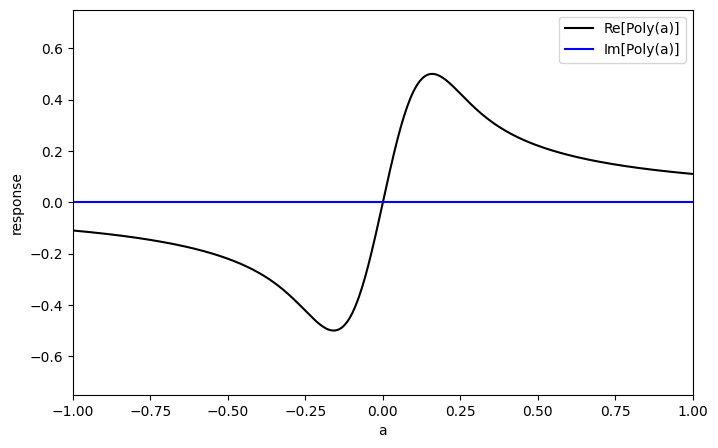

In [9]:
import numpy as np
from pyqsp.angle_sequence import Polynomial, QuantumSignalProcessingPhases

poly = Polynomial(pcoefs)

# choosing 'z' this basis since P(1)=1 and won't to avoid the QSP basis change. Anyway, we are not measuring directly this qubit.
ang_seq = QuantumSignalProcessingPhases(
    poly, signal_operator="Wx", method="laurent", measurement="x"
)
pyqsp.response.PlotQSPResponse(ang_seq, signal_operator="Wx", measurement="x")

In [10]:
# change the R(x) to W(x), as the phases are in the W(x) conventions
phases = np.array(ang_seq)
phases[1:-1] = phases[1:-1] - np.pi / 2
phases[0] = phases[0] - np.pi / 4
phases[-1] = phases[-1] + (2 * (len(phases) - 1) - 1) * np.pi / 4

# verify conventions. minus is due to exp(-i*phi*z) in qsvt in comparison to qsp
phases = -2 * phases

In [11]:
@qfunc
def main(
    state: Output[QNum],
    block: Output[QBit],
    aux: Output[QBit],
) -> None:
    full_state = QArray("full_state")
    
    prepare_amplitudes(b.tolist(), 0.0, state)

    allocate(1, block)
    bind([state, block], full_state)

    my_qsvt_inversion(
        phase_seq=list(phases),
        u=lambda arg0: unitary(
            # Here we can just use the transpose of A as is it real valued
            elements=U_a.T.tolist(),
            target=arg0,
        ),
        state=full_state,
        aux=aux,
    )

    bind(full_state, [state, block])

In [12]:
from classiq import create_model
from classiq.execution import (
    ClassiqBackendPreferences,
    ClassiqSimulatorBackendNames,
    ExecutionPreferences,
)

# convert the functions to a qmod model
qmod = create_model(main)

# we will want to execute this qmod on a state-vector simulator:
execution_preferences = ExecutionPreferences(
    num_shots=1,
    backend_preferences=ClassiqBackendPreferences(
        backend_name=ClassiqSimulatorBackendNames.SIMULATOR_STATEVECTOR
    ),
)
qmod = set_execution_preferences(qmod, execution_preferences)

write_qmod(qmod, name="qsvt_matrix_inversion", decimal_precision=15)

In [18]:
import classiq
classiq.authenticate()


Your user code: CRDC-GHCV
If a browser doesn't automatically open, please visit this URL from any trusted device: https://auth.classiq.io/activate?user_code=CRDC-GHCV


In [19]:
qprog = synthesize(qmod)
show(qprog)

Quantum program link: https://platform.classiq.io/circuit/2wvHPYuJs14S3Zrw9dGuXVgGkRL?login=True&version=0.78.0


In [20]:
result = execute(qprog).result_value()


In [21]:
def parse_results(result):
    parsed_state_vector = result.parsed_state_vector

    d = {
        int(parsed_state["state"]): parsed_state.amplitude
        for parsed_state in parsed_state_vector
        if parsed_state["aux"] == parsed_state["block"] == 0.0
    }

    values = np.array([d[i] for i in range(len(d))])
    global_phase = np.angle(values)[0]
    values = np.real(values / np.exp(1j * global_phase))
    normalization = np.linalg.norm(
        [
            parsed_state.amplitude
            for parsed_state in parsed_state_vector
            if parsed_state["block"] == 0.0
        ]
    )
    computed_x = values / normalization
    return computed_x

In [22]:
parsed_state_vector = result.parsed_state_vector

d = {
    parsed_state["state"]: parsed_state.amplitude
    for parsed_state in parsed_state_vector
    if parsed_state["aux"] == parsed_state["block"] == 0.0
}


computed_x = parse_results(result)
print(computed_x)

[ 0.29198316  0.02042706  0.13432705 -0.24664573]


In [23]:
expected_x = 1 / (2 * kappa) * (np.linalg.inv(A) @ b)
print(expected_x)

assert np.allclose(computed_x, expected_x, rtol=0.1)

[ 0.29134204  0.02176207  0.13386997 -0.24527315]
